In [18]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel

In [ ]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_test3/tables')
# SAMPLE = 'stopMLstudy_M1000_988_ct20_2018'
# SAMPLE = 'C1N2MLstudy_M400_388_ct0p2_2018_SP2_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
SAMPLE = 'C1N2MLstudy_M400_388_ct0p2_2018_SP2_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)


In [3]:
table.keys()

dict_keys(['0.00,0.00', '0.00,0.10', '0.10,0.00', '0.10,0.10'])

In [4]:
table['0.00,0.00'].keys()

dict_keys(['sig_NA', 'sig_NB', 'sig_NC', 'sig_ND', 'bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND', 'sig_NA_unc', 'sig_NB_unc', 'sig_NC_unc', 'sig_ND_unc', 'bkg_NA_unc', 'bkg_NB_unc', 'bkg_NC_unc', 'bkg_ND_unc', 'Z_A', 'Z_B', 'Z_C', 'Z_D', 'Z_noncl_A', 'Z_noncl_B', 'Z_noncl_C', 'Z_noncl_D', 'noncl', 'noncl_unc'])

In [5]:
table['0.00,0.00']['bkg_NA'].loc[0.2, 0.8]

4415.365088459718

In [6]:
(table['0.00,0.00']['bkg_NB'].loc[0.2, 0.8] * 
 table['0.00,0.00']['bkg_NC'].loc[0.2, 0.8] /
 table['0.00,0.00']['bkg_ND'].loc[0.2, 0.8])

965.5913334271387

In [7]:
# fig = plt.figure()
# rel_err_f = (table['0.00,0.00']['bkg_NB'] * table['0.00,0.00']['bkg_NC']) / (table['0.00,0.00']['bkg_NA'] * table['0.00,0.00']['bkg_ND'])
# pcm = plt.pcolormesh(rel_err_f.index, rel_err_f.columns, rel_err_f.T,
#         cmap="viridis", vmin=0.5, vmax=2, shading="auto")
# plt.xlim(0.5, 1.0)
# plt.ylim(0.5, 1.0)
# 
# # Shared colorbar
# cbar = fig.colorbar(pcm, shrink=0.90)
# cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")
# plt.show()


### Non-Closure

In [ ]:
np.any(noncl < 0)

False

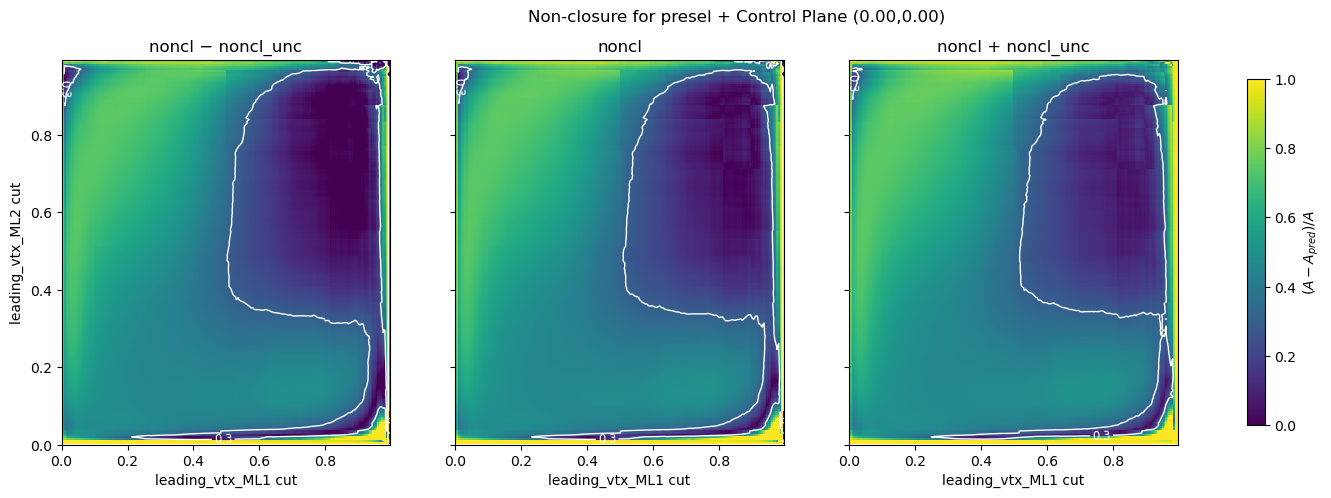

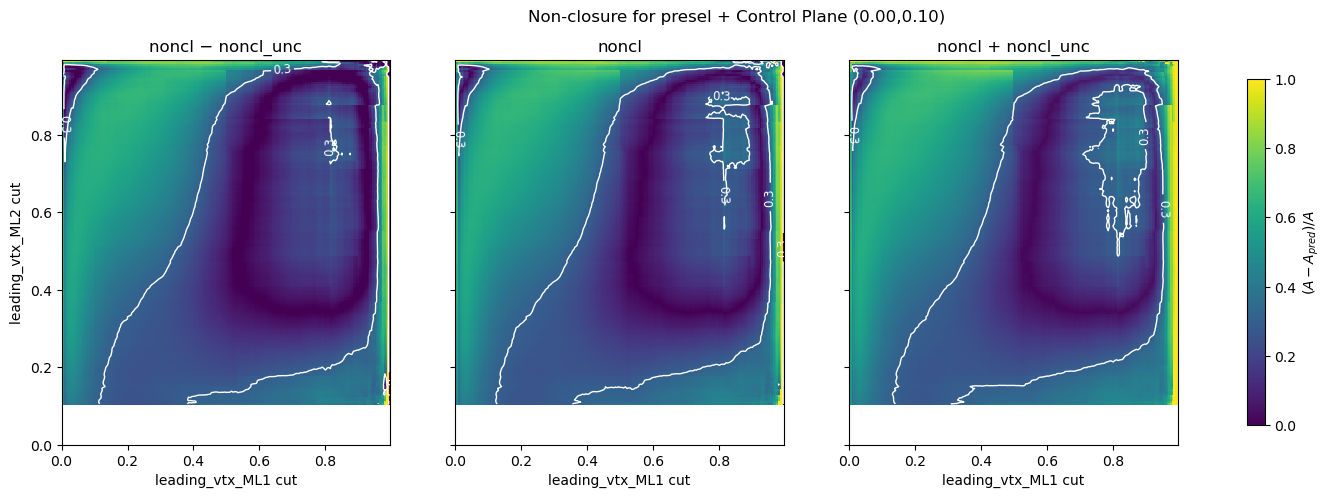

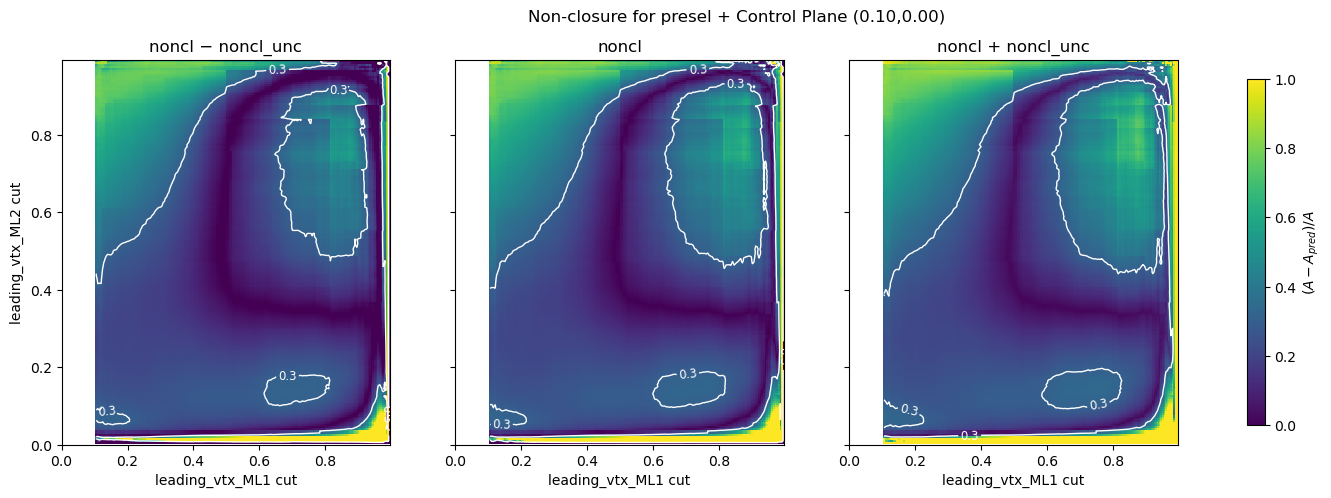

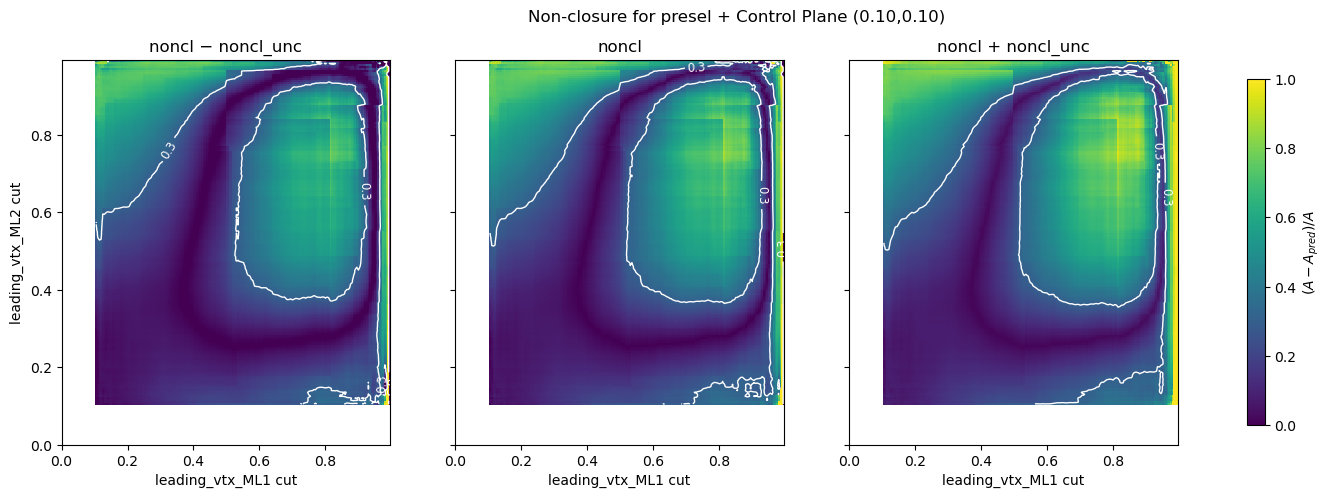

In [17]:
sig_tag = SAMPLE

def plot_pair(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    # base_levels = [-0.30, 0.30]
    base_levels = [0.30]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    # vmin = -1
    vmin = 0
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0., Z_noncl_minus.index.max())
    ax.set_ylim(0., Z_noncl_minus.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0., Z_noncl.index.max())
    ax.set_ylim(0., Z_noncl.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    ax.set_xlim(0., Z_noncl_plus.index.max())
    ax.set_ylim(0., Z_noncl_plus.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()


# --- Loop over all tables ---
for key, sub in table.items():
    noncl          = sub["noncl"]
    noncl_plus1s   = sub["noncl"] + sub["noncl_unc"]
    noncl_minus1s  = sub["noncl"] - sub["noncl_unc"]

    plot_pair(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + Control Plane ({key})")
    # print(np.any(noncl < 0))


### Plot only the range -0.20 < noncl < 0.20

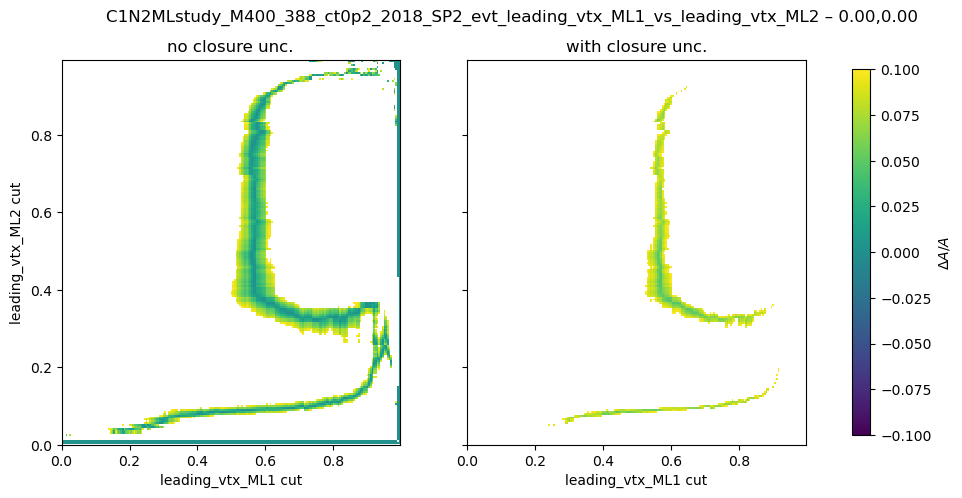

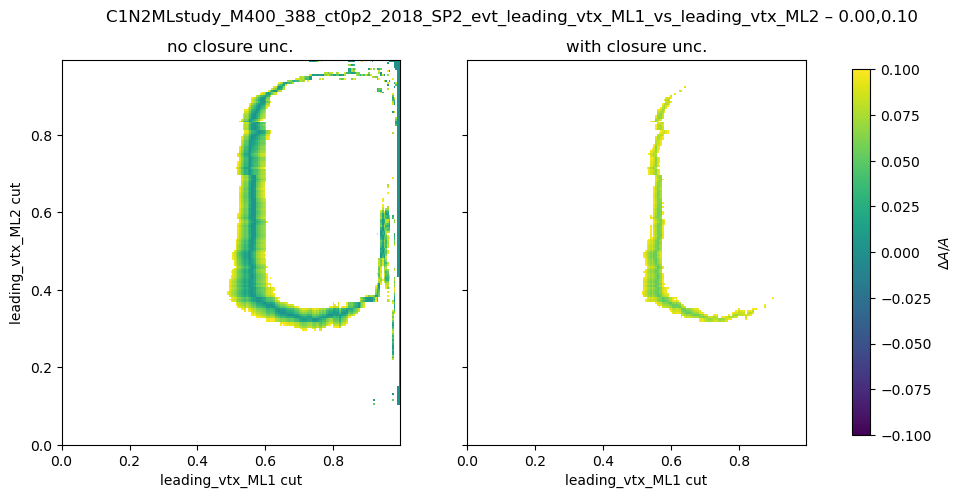

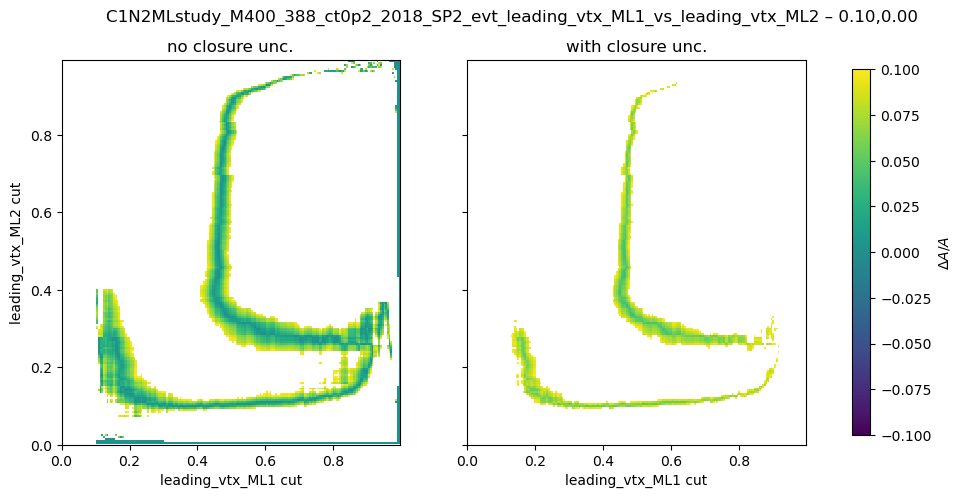

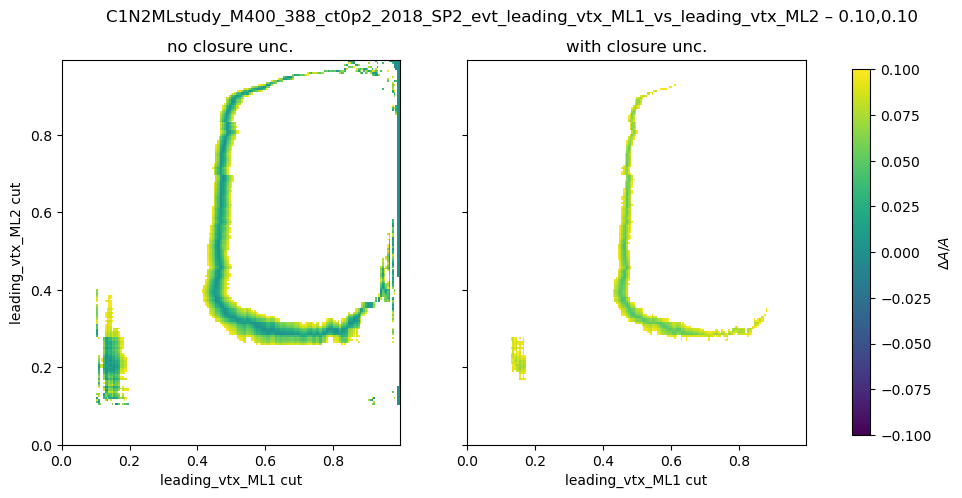

In [9]:
import numpy as np
import matplotlib.pyplot as plt

sig_tag = SAMPLE  # keep your original variable

def plot_pair(Z_left, Z_right, sig_tag):
    # Range of interest
    low, high = -0.1, 0.1

    # Common levels based on both matrices
    base_levels = [low, high]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Mask values outside the region of interest (without modifying originals)
    Z_left_vals = Z_left.values
    Z_right_vals = Z_right.values

    Zmasked_left = np.ma.masked_outside(Z_left_vals,  low, high)
    Zmasked_right = np.ma.masked_outside(Z_right_vals, low, high)

    # Color scale: limited to the range of interest
    vmin = low
    vmax = high

    # Optional: show masked values as light grey if they appear
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="white")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title("no closure unc.")
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Zmasked_left.T,
        cmap=cmap, vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_left.index, Z_left.columns, Zmasked_left.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0., Z_left.index.max())
    ax.set_ylim(0., Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title("with closure unc.")
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Zmasked_right.T,
        cmap=cmap, vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_right.index, Z_right.columns, Zmasked_right.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0., Z_right.index.max())
    ax.set_ylim(0., Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"$\Delta A / A$")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

for key, sub in table.items():
    noncl        = sub["noncl"]
    noncl_plus1s = sub["noncl"] + sub["noncl_unc"]

    plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} – {key}")


### Significance

In [10]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_test3/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct0p2_2018_all_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
# SAMPLE = 'stop_M600_588_ct20_2018'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

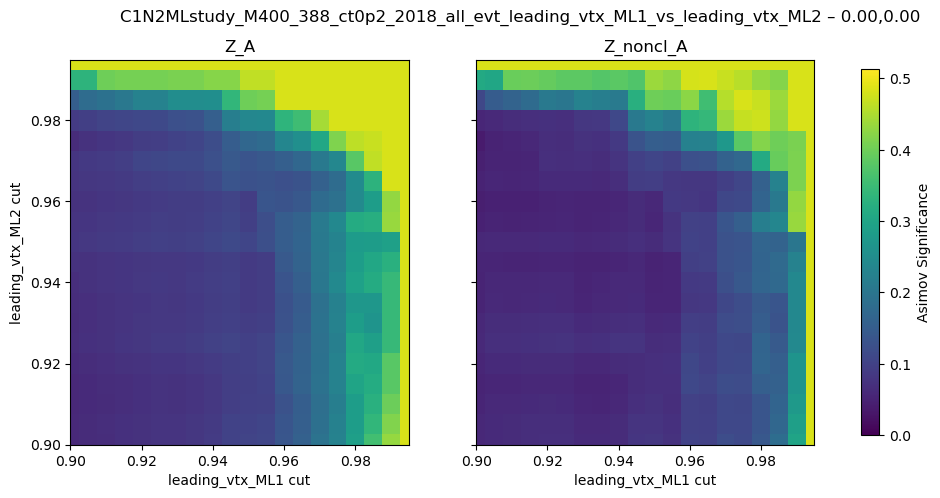

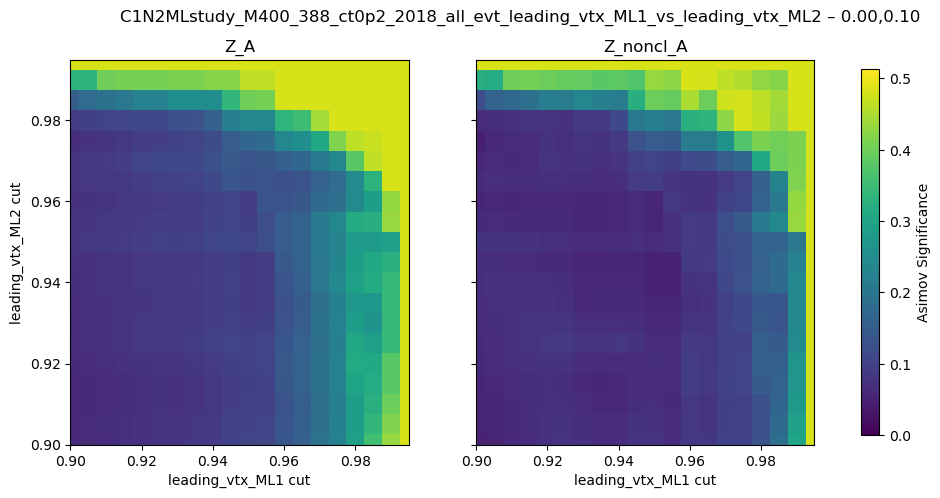

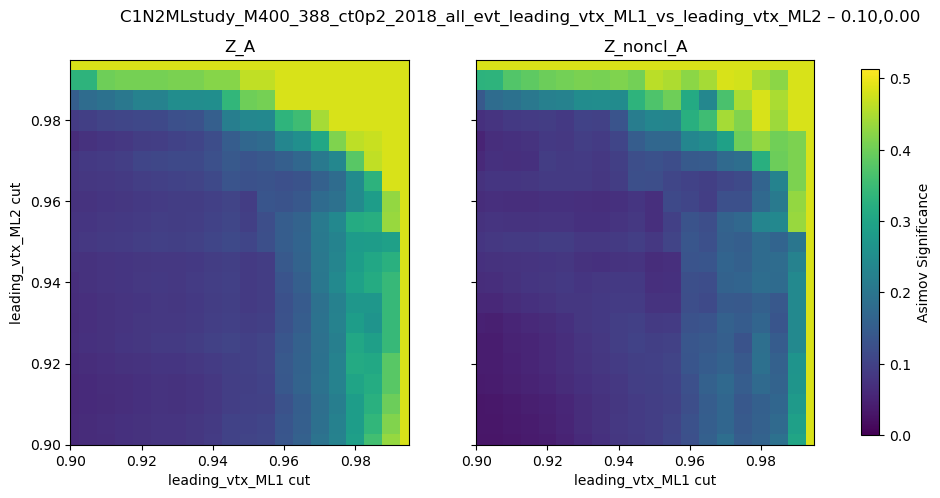

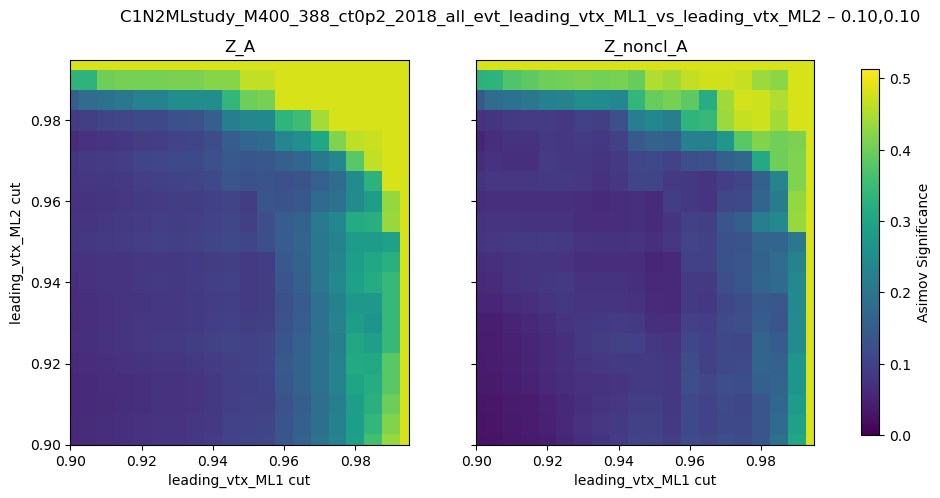

In [11]:
sig_tag = SAMPLE

def plot_pair(Z_left, Z_right, sig_tag):
    # Common levels based on both matrices
    base_levels = [1, 2, 3]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Consistent color scale across both plots
    vmin = 0 # np.nanmin([np.nanmin(Z_left.values), np.nanmin(Z_right.values)])
    vmax = global_max

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title('Z_A')
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Z_left.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(Z_left.index, Z_left.columns, Z_left.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0.9, Z_left.index.max())
    ax.set_ylim(0.9, Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title('Z_noncl_A')
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Z_right.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(Z_right.index, Z_right.columns, Z_right.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0.9, Z_right.index.max())
    ax.set_ylim(0.9, Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"Asimov Significance")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

for key, sub in table.items():
    noncl        = sub['Z_A']
    noncl_plus1s = sub['Z_noncl_A']

    plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} – {key}")


### C1N2

In [12]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_test3/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018'
# SAMPLE = 'stop_M600_588_ct20_2018'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_test3/tables/C1N2MLstudy_M400_388_ct20_2018/gridsearch_disco.pkl'

In [ ]:
tables = table['0.00,0.00']

x_max, y_max = tables['Z_noncl_A'].stack().idxmax()

print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.93, 0.985
nonclosure: -0.06837062278434702 +/- 0.4895439288307625
significance without non-closure unc.: 3.4225021619460096
significance with non-closure unc.: 3.412476374358243

Signal counts in A: 7.030025369078537
Background counts in A: 0.9821283565495138


In [ ]:
tables = table['0.00,0.00']

x_max, y_max = 0.9450000000000001, 0.985

print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.9450000000000001, 0.985
nonclosure: 0.044978591925652345 +/- 0.5136148341506419
significance without non-closure unc.: 3.1857259340200854
significance with non-closure unc.: 3.1832437388133896

Signal counts in A: 6.32655544618328
Background counts in A: 0.6715428488517164


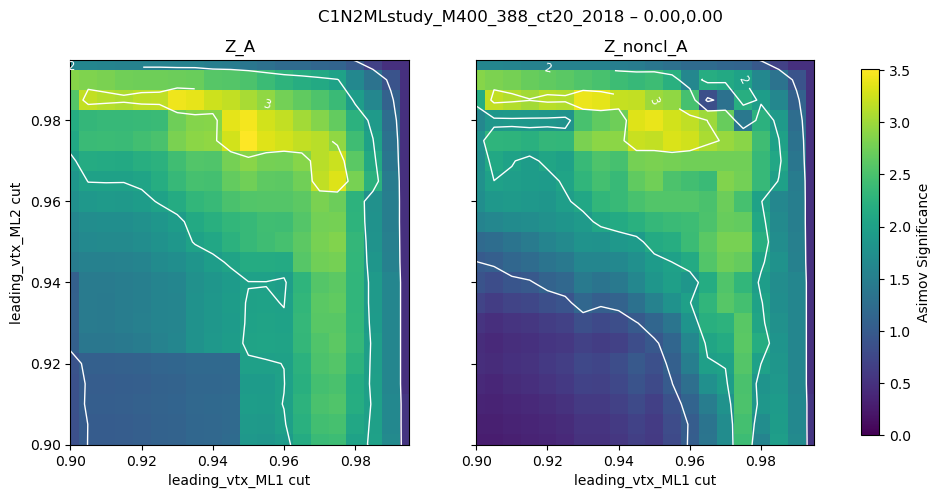

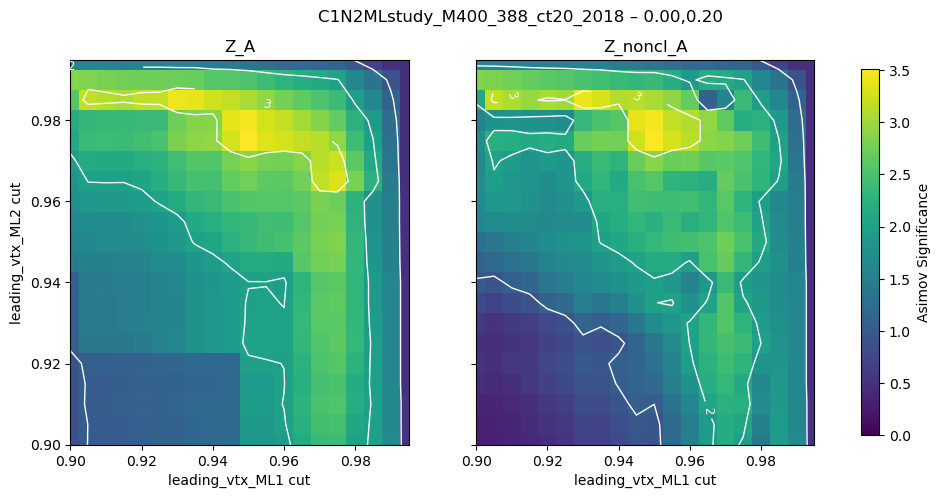

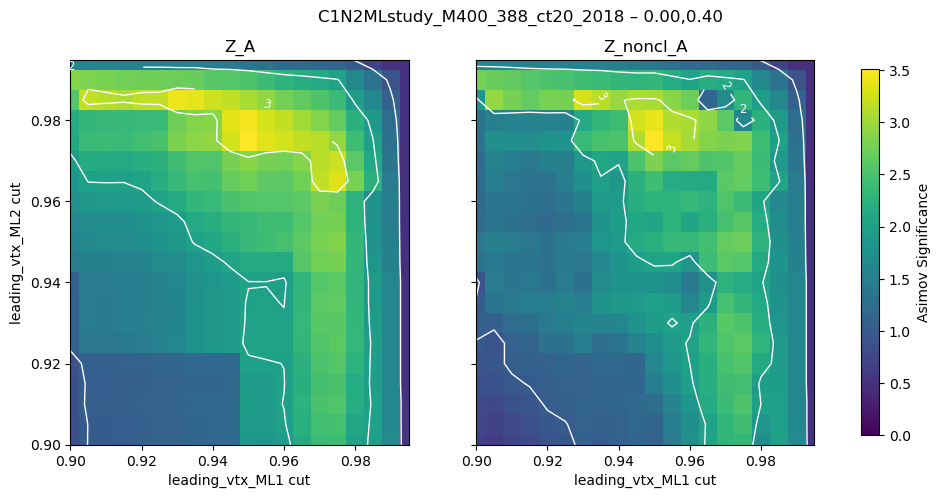

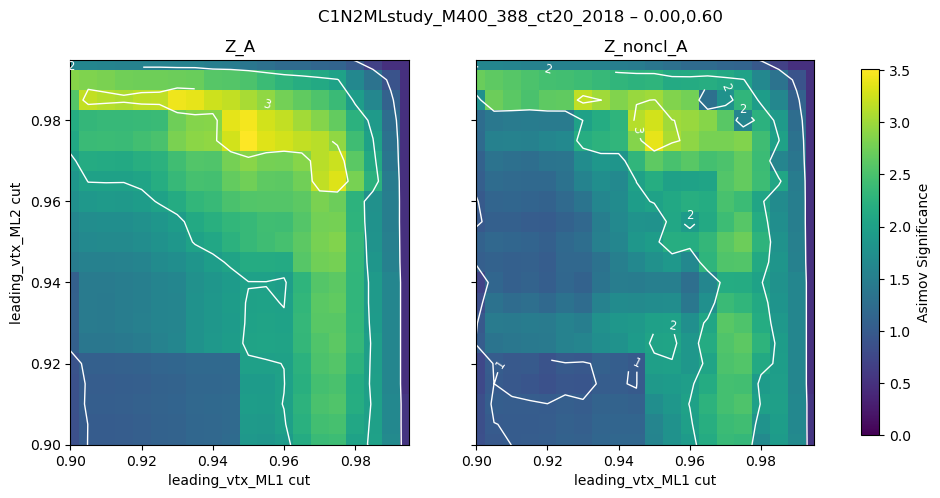

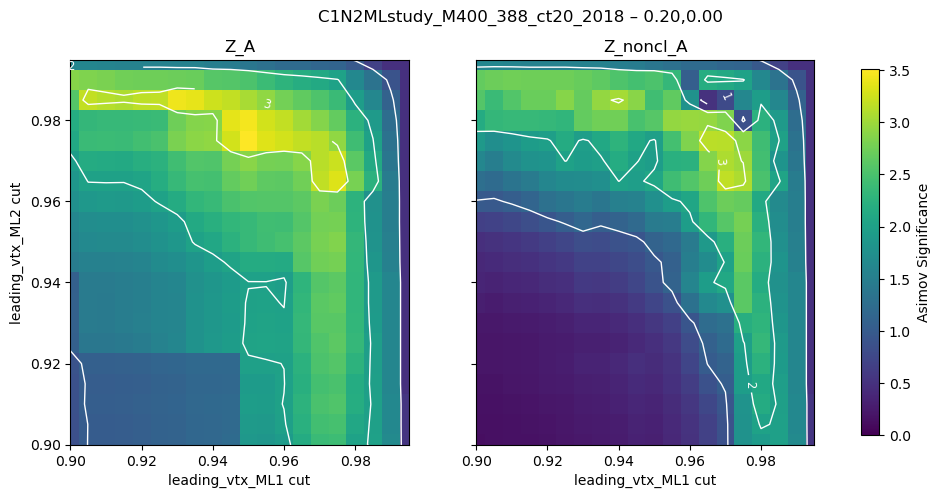

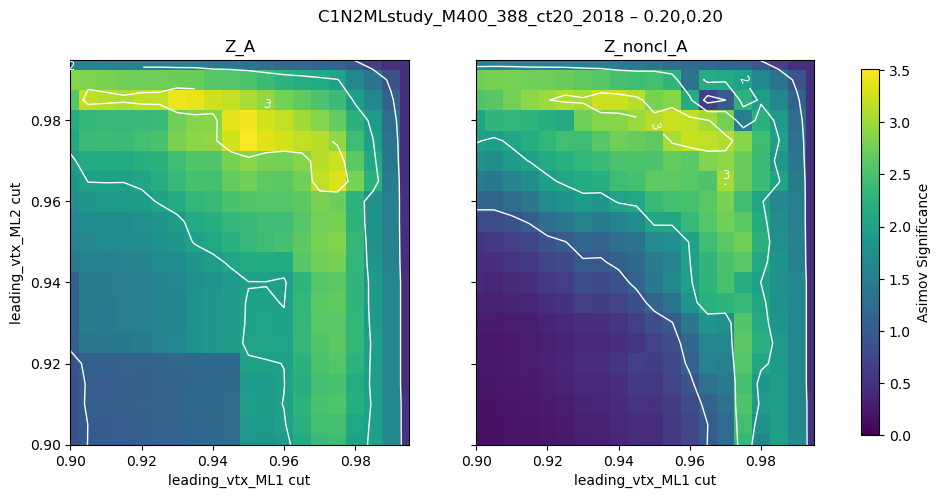

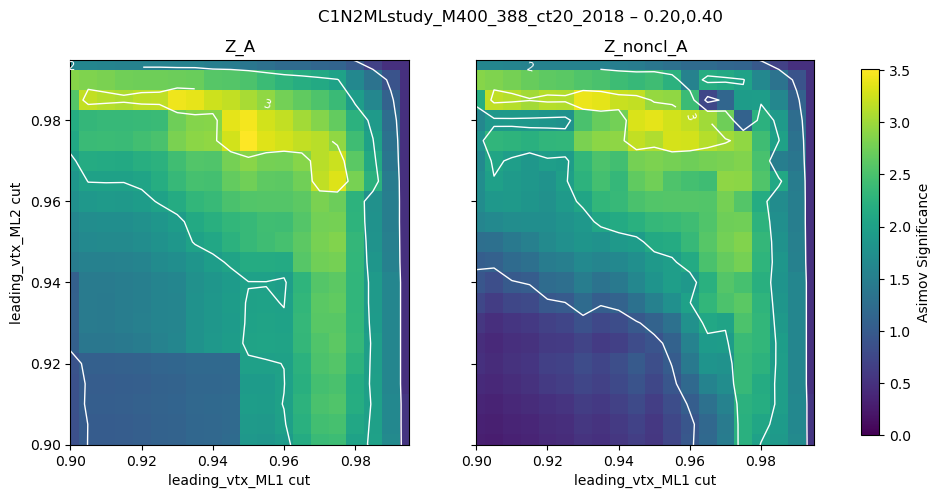

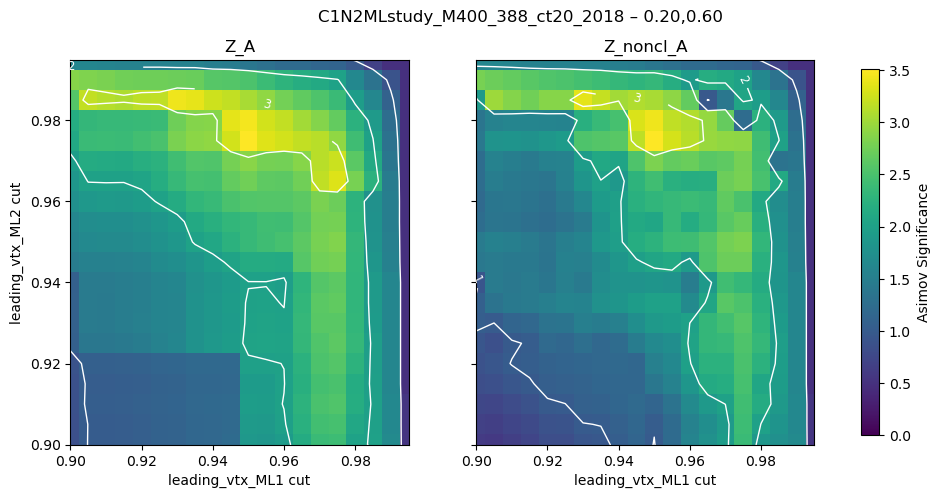

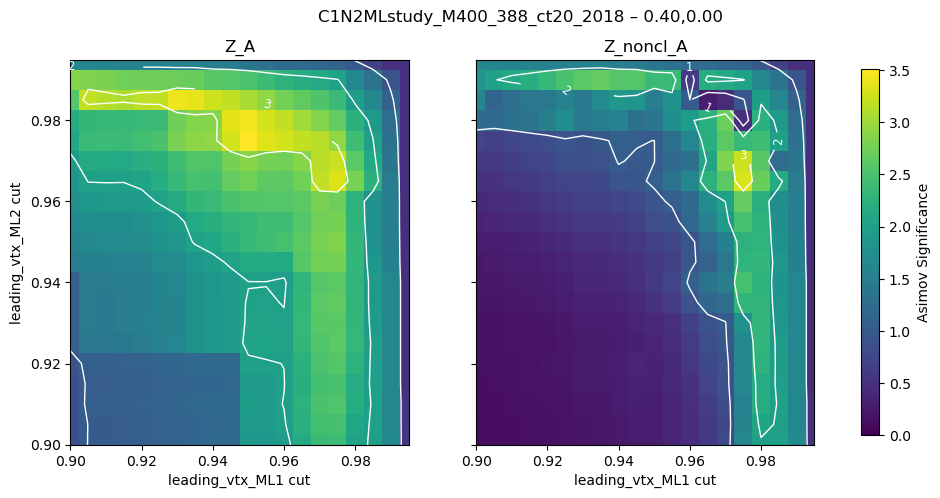

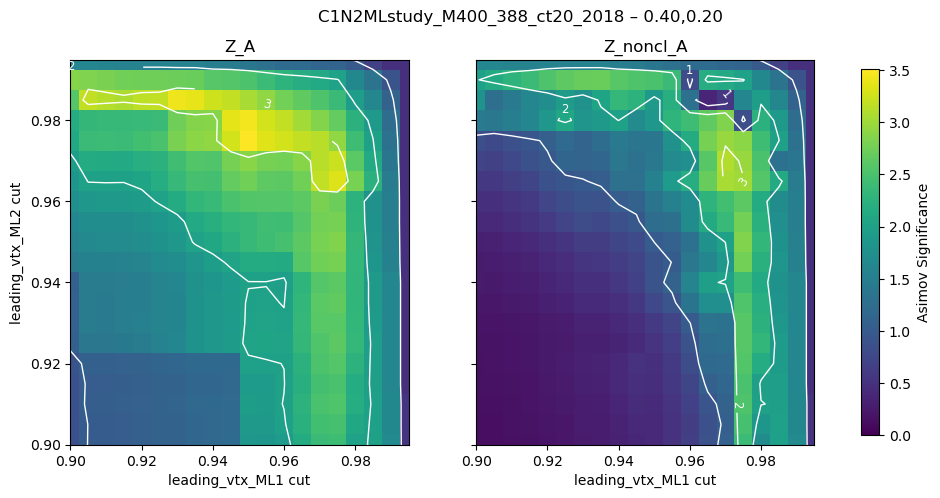

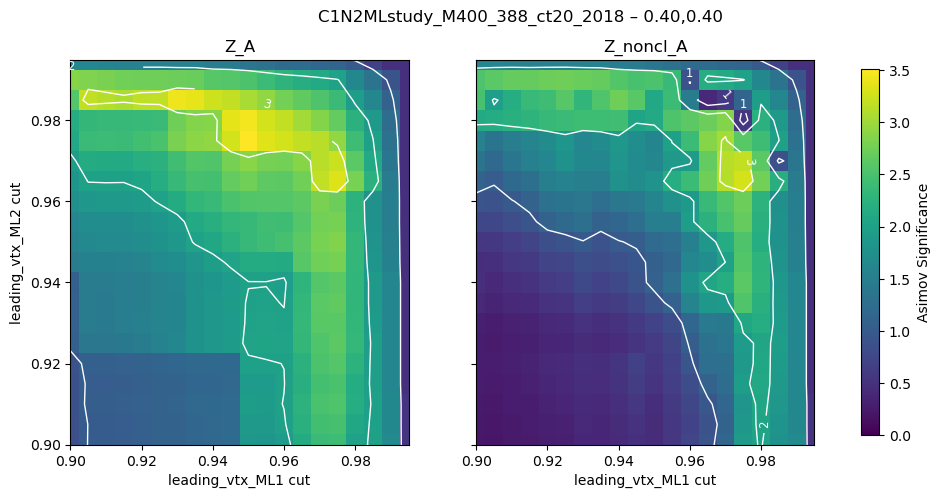

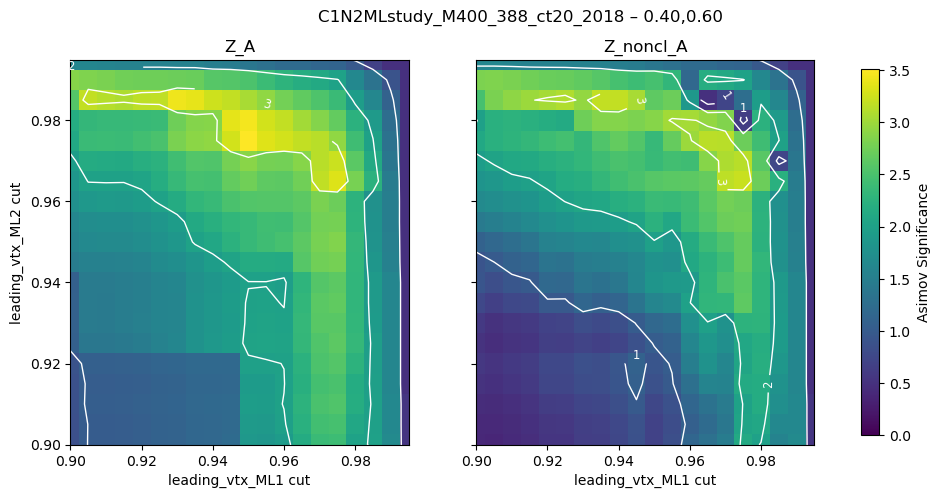

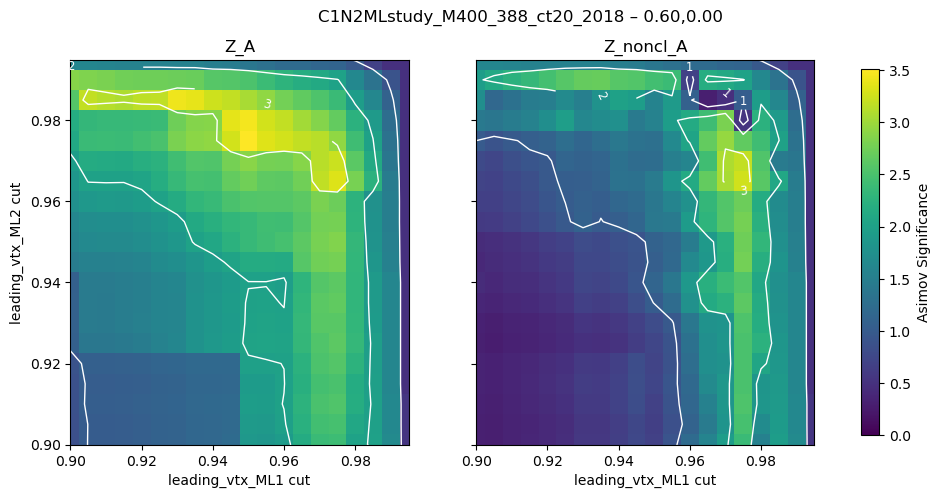

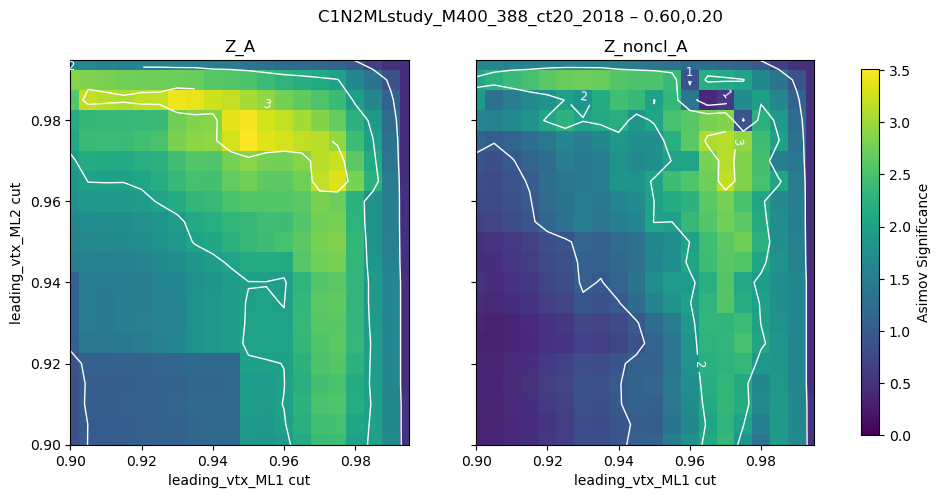

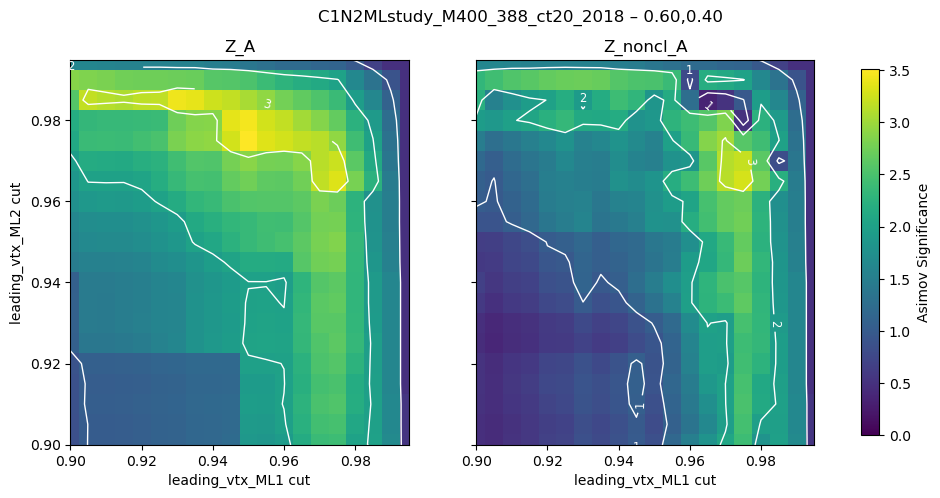

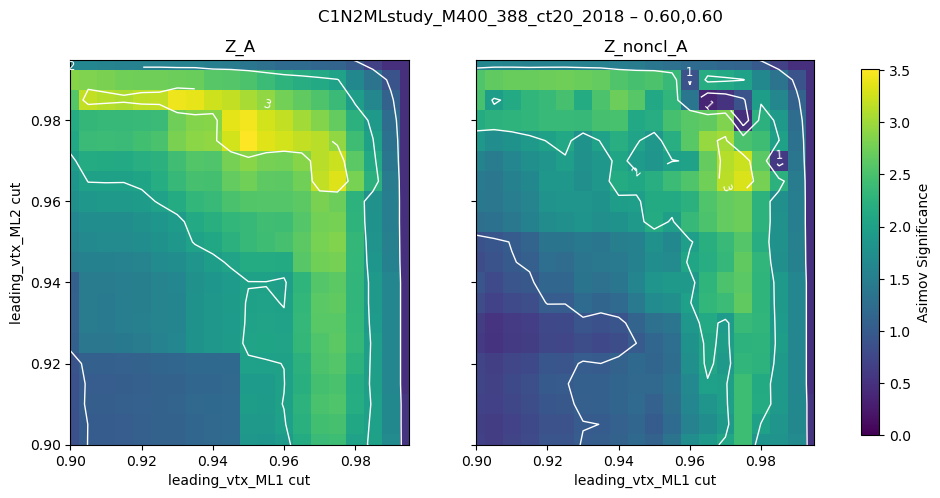

In [ ]:
sig_tag = SAMPLE

def plot_pair(Z_left, Z_right, sig_tag):
    # Common levels based on both matrices
    base_levels = [1, 2, 3]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Consistent color scale across both plots
    vmin = 0 # np.nanmin([np.nanmin(Z_left.values), np.nanmin(Z_right.values)])
    vmax = global_max

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title('Z_A')
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Z_left.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(Z_left.index, Z_left.columns, Z_left.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0.9, Z_left.index.max())
    ax.set_ylim(0.9, Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title('Z_noncl_A')
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Z_right.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(Z_right.index, Z_right.columns, Z_right.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0.9, Z_right.index.max())
    ax.set_ylim(0.9, Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"Asimov Significance")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

for key, sub in table.items():
    noncl        = sub['Z_A']
    noncl_plus1s = sub['Z_noncl_A']

    plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} – {key}")


# Closure in data

In [ ]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel


HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_blind/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt_withdata'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)


In [ ]:
table['0.00,0.00'].keys()

dict_keys(['sig_NA', 'sig_NB', 'sig_NC', 'sig_ND', 'bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND', 'sig_NA_unc', 'sig_NB_unc', 'sig_NC_unc', 'sig_ND_unc', 'bkg_NA_unc', 'bkg_NB_unc', 'bkg_NC_unc', 'bkg_ND_unc', 'Z_A', 'Z_B', 'Z_C', 'Z_D', 'Z_noncl_A', 'Z_noncl_B', 'Z_noncl_C', 'Z_noncl_D', 'noncl', 'noncl_unc'])

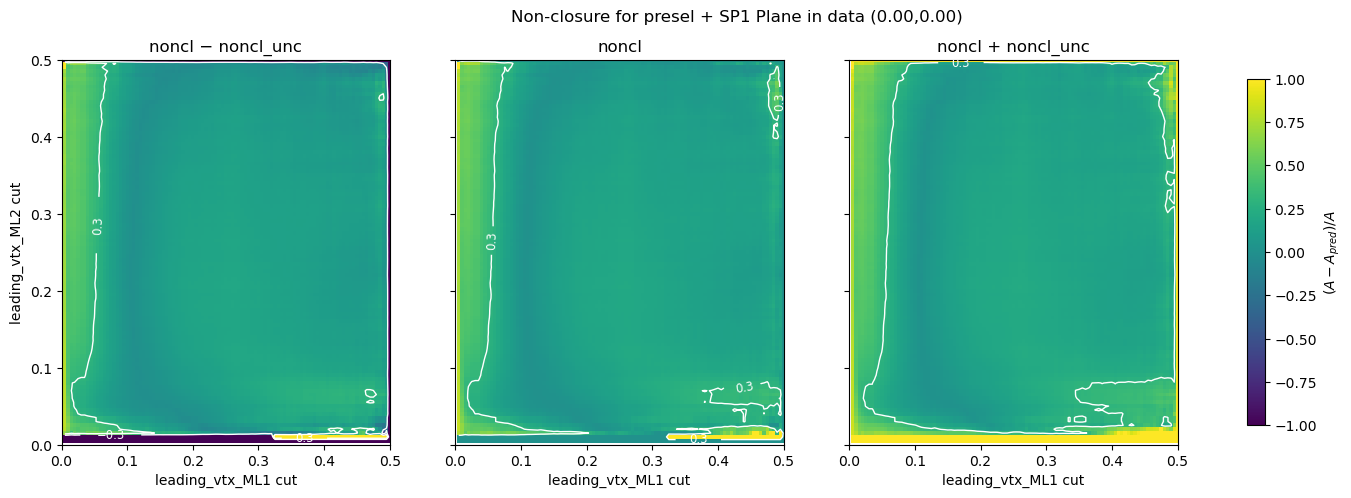

In [ ]:
def plot_pair(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    base_levels = [-0.30, 0.30]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin = -1
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()


# --- Loop over all tables ---
for key, sub in table.items():
    noncl          = sub["noncl"]
    noncl_plus1s   = sub["noncl"] + sub["noncl_unc"]
    noncl_minus1s  = sub["noncl"] - sub["noncl_unc"]

    plot_pair(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in data ({key})")


In [ ]:
table['0.00,0.00']['Z_A'].loc[:0.495,:0.495]

,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,0.050,...,0.450,0.455,0.460,0.465,0.470,0.475,0.480,0.485,0.490,0.495
0.005,0.000538,0.000538,0.000538,0.000540,0.000544,0.000546,0.000546,0.000557,0.000563,0.000567,...,0.001068,0.001155,0.001103,0.001033,0.001159,0.001271,0.001100,0.001146,0.001685,0.003186
0.010,0.000535,0.000535,0.000536,0.000537,0.000541,0.000544,0.000544,0.000554,0.000560,0.000564,...,0.001049,0.001133,0.001118,0.001047,0.001174,0.001287,0.001114,0.001160,0.001710,0.003218
0.015,0.000539,0.000539,0.000540,0.000541,0.000545,0.000548,0.000548,0.000559,0.000565,0.000569,...,0.001059,0.001144,0.001128,0.001056,0.001185,0.001297,0.001124,0.001169,0.001723,0.003227
0.020,0.000544,0.000544,0.000545,0.000546,0.000550,0.000553,0.000553,0.000564,0.000570,0.000574,...,0.001066,0.001151,0.001135,0.001063,0.001193,0.001306,0.001130,0.001176,0.001733,0.003235
0.025,0.000550,0.000550,0.000551,0.000552,0.000556,0.000559,0.000559,0.000570,0.000576,0.000580,...,0.001075,0.001160,0.001144,0.001071,0.001202,0.001314,0.001139,0.001185,0.001745,0.003252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.475,0.000603,0.000603,0.000604,0.000607,0.000611,0.000619,0.000619,0.000644,0.000658,0.000675,...,0.012848,0.014335,0.015602,0.018259,0.021267,0.023522,0.028174,0.033270,0.043895,0.073494
0.480,0.000710,0.000710,0.000711,0.000714,0.000718,0.000729,0.000729,0.000757,0.000772,0.000793,...,0.017236,0.019111,0.020552,0.023751,0.028174,0.030697,0.036912,0.041518,0.053230,0.090658
0.485,0.000939,0.000939,0.000941,0.000944,0.000949,0.000964,0.000964,0.001003,0.001025,0.001050,...,0.023297,0.024972,0.026329,0.029560,0.034734,0.037503,0.045650,0.053230,0.064326,0.100747
0.490,0.001441,0.001441,0.001443,0.001448,0.001457,0.001480,0.001480,0.001536,0.001566,0.001604,...,0.033743,0.036341,0.038746,0.044754,0.050794,0.054548,0.064326,0.076292,0.095373,0.122905


In [ ]:
up_lim = 0.495
tables = table['0.00,0.00']
if_signal_present = tables['sig_NA'].loc[:up_lim,:up_lim] != 0.
tables['Z_A'].loc[:up_lim,:up_lim][if_signal_present]


print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.4, 0.4
nonclosure: 0.12420376360392993 +/- 0.029028245611914586
significance without non-closure unc.: 0.001329079016626034
significance with non-closure unc.: 0.0011332166837616146

Signal counts in A: 0.30751772945747086
Background counts in A: 1856.0


In [ ]:
table_data = table

### MC to compare

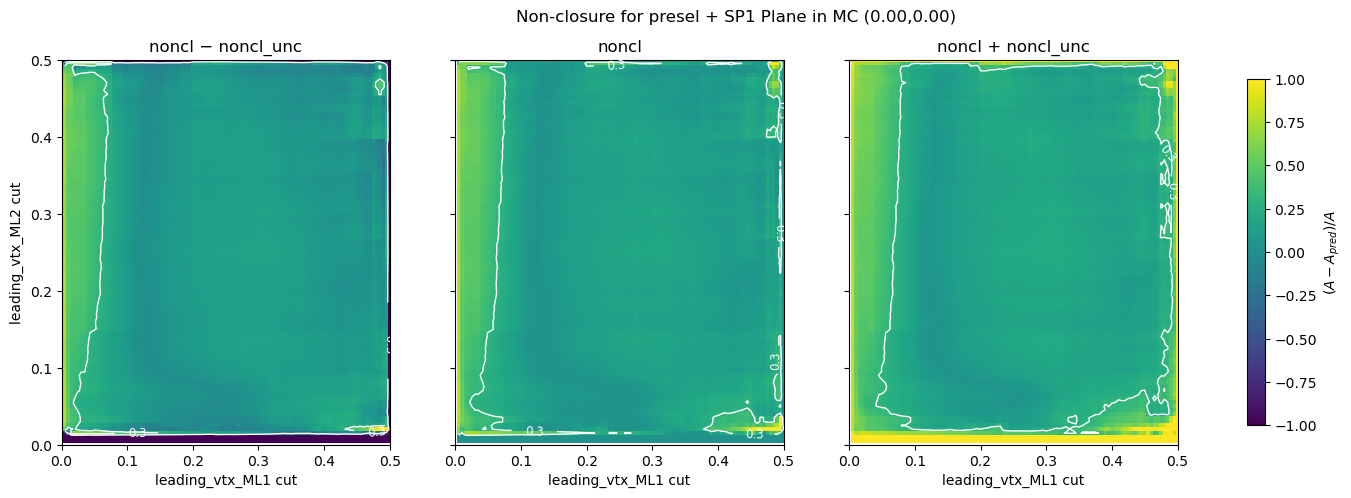

In [ ]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_blind/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

# --- Loop over all tables ---
for key, sub in table.items():
    noncl          = sub["noncl"]
    noncl_plus1s   = sub["noncl"] + sub["noncl_unc"]
    noncl_minus1s  = sub["noncl"] - sub["noncl_unc"]

    plot_pair(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in MC ({key})")

In [ ]:
up_lim = 0.495
tables = table['0.00,0.00']
if_signal_present = tables['sig_NA'].loc[:up_lim,:up_lim] != 0.
tables['Z_A'].loc[:up_lim,:up_lim][if_signal_present]


print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.4, 0.4
nonclosure: 0.1252217395177022 +/- 0.05888399034867424
significance without non-closure unc.: 0.001996094829154749
significance with non-closure unc.: 0.0017088001671161175

Signal counts in A: 0.30751772945747086
Background counts in A: 1207.5628415417304


In [ ]:
delta_noncl = table_data['0.00,0.00']['noncl'] - table['0.00,0.00']['noncl']

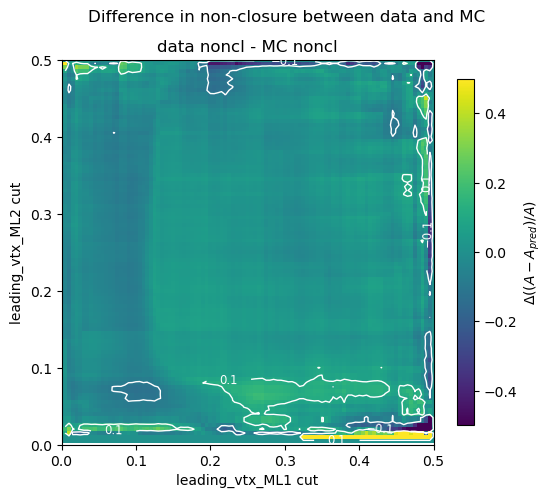

In [ ]:
def plot_single(Z, suptitle, title="noncl"):
    # Common contour levels
    base_levels = [-0.10, 0.10]
    global_max = np.nanmax(Z.values)
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin = -0.5
    vmax =  0.5

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle(suptitle)

    ax.set_title(title)
    pcm = ax.pcolormesh(
        Z.index, Z.columns, Z.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont = ax.contour(
            Z.index, Z.columns, Z.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont, fontsize="smaller")

    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # Colorbar
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.90)
    cbar.ax.set_ylabel(r"$\Delta ((A - A_{pred}) / A)$")

    plt.show()

plot_single(delta_noncl, suptitle="Difference in non-closure between data and MC", title="data noncl - MC noncl")


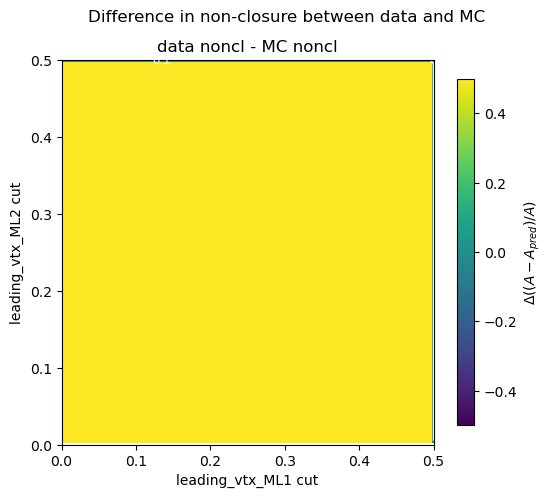

In [ ]:
def plot_single(Z, suptitle, title="noncl"):
    # Common contour levels
    base_levels = [-0.10, 0.10]
    global_max = np.nanmax(Z.values)
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin = -0.5
    vmax =  0.5

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle(suptitle)

    ax.set_title(title)
    pcm = ax.pcolormesh(
        Z.index, Z.columns, Z.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont = ax.contour(
            Z.index, Z.columns, Z.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont, fontsize="smaller")

    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # Colorbar
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.90)
    cbar.ax.set_ylabel(r"$\Delta ((A - A_{pred}) / A)$")

    plt.show()

plot_single(delta_noncl, suptitle="Difference in non-closure between data and MC", title="data noncl - MC noncl")



plot_single(table_data['0.00,0.00']['bkg_NA'], suptitle="Difference in non-closure between data and MC", title="data noncl - MC noncl")

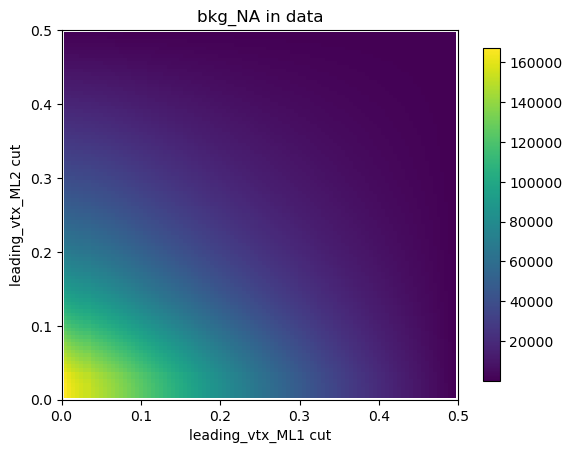

In [ ]:
X_d = table_data['0.00,0.00']['bkg_NA']
X_d[X_d == 0] = np.nan

fig = plt.figure()

pcm = plt.pcolormesh(X_d.index, X_d.columns, X_d.T,
                     cmap="viridis", shading="nearest"
                     )
plt.xlim(0., 0.5)
plt.ylim(0., 0.5)
cbar = fig.colorbar(pcm, shrink=0.90)
plt.title('bkg_NA in data')
plt.xlabel("leading_vtx_ML1 cut")
plt.ylabel("leading_vtx_ML2 cut")
plt.show()

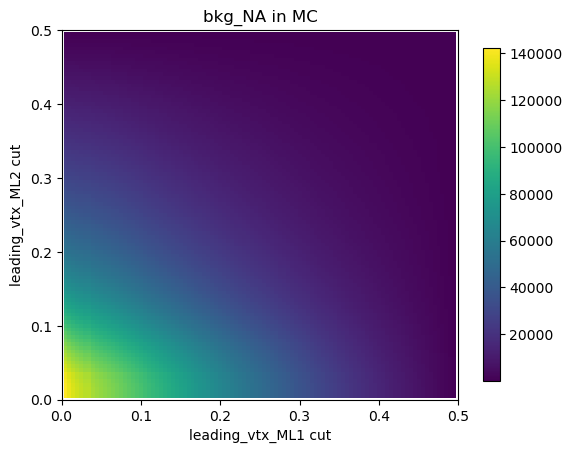

In [ ]:
X_b = table['0.00,0.00']['bkg_NA']
X_b[X_b == 0] = np.nan

fig = plt.figure()

pcm = plt.pcolormesh(X_b.index, X_b.columns, X_b.T,
                     cmap="viridis", shading="auto"
                     )
plt.xlim(0., 0.5)
plt.ylim(0., 0.5)
cbar = fig.colorbar(pcm, shrink=0.90)
plt.title('bkg_NA in MC')
plt.xlabel("leading_vtx_ML1 cut")
plt.ylabel("leading_vtx_ML2 cut")
plt.show()

In [ ]:
# R = X_d / X_b

# fig = plt.figure()

# pcm = plt.pcolormesh(R.index, R.columns, R.T,
#                      cmap="viridis", vmin=0, vmax=2, shading="auto"
#                      )
# plt.xlim(0., 0.5)
# plt.ylim(0., 0.5)
# cbar = fig.colorbar(pcm, shrink=0.90)
# plt.title('Data / MC ratio of background counts in A')
# plt.xlabel("leading_vtx_ML1 cut")
# plt.ylabel("leading_vtx_ML2 cut")
# plt.show()

## CP_evt

In [28]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_test3_reverse/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_CP_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)


FileNotFoundError: [Errno 2] No such file or directory: '/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_test3_reverse/tables/C1N2MLstudy_M400_388_ct20_2018_CP_evt_leading_vtx_ML1_vs_leading_vtx_ML2/gridsearch_disco.pkl'

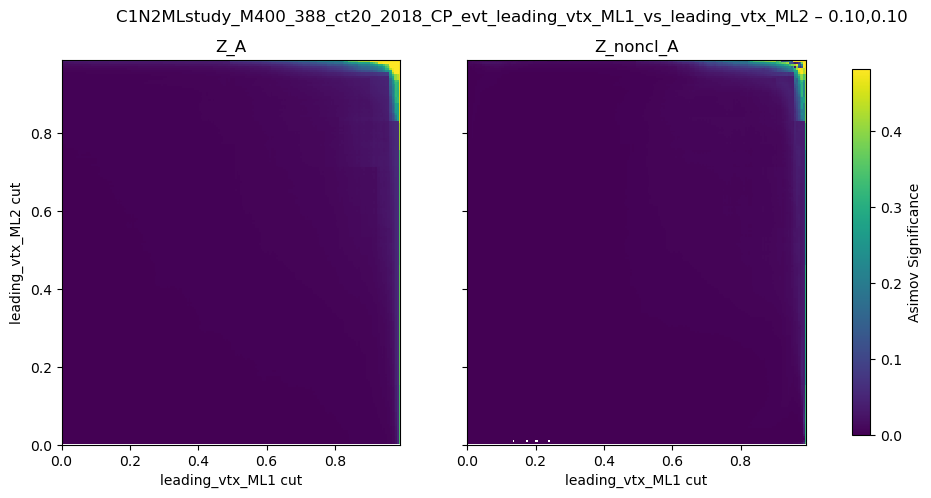

In [31]:
sig_tag = SAMPLE

def plot_pair(Z_left, Z_right, sig_tag):
    # Common levels based on both matrices
    base_levels = [1, 2, 3]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Consistent color scale across both plots
    vmin = 0 # np.nanmin([np.nanmin(Z_left.values), np.nanmin(Z_right.values)])
    vmax = global_max# 0.1# global_max

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title('Z_A')
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Z_left.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(Z_left.index, Z_left.columns, Z_left.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0.0, 0.99) # Z_left.index.max())
    ax.set_ylim(0.0, 0.99) # Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title('Z_noncl_A')
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Z_right.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(Z_right.index, Z_right.columns, Z_right.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0.0, 0.99) # Z_right.index.max())
    ax.set_ylim(0.0, 0.99) # Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"Asimov Significance")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

sub = {}
sub['Z_A'] = table['0.00,0.00']['Z_A']
sub['Z_noncl_A'] = table['0.00,0.00']['Z_noncl_A']
noncl        = sub['Z_A']
noncl_plus1s = sub['Z_noncl_A']

plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} – {key}")
